In [1]:
import cv2
print(cv2.__version__)

4.13.0


In [2]:
!pip install mtcnn facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 67.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 78.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 74.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 50.2 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 945.5

In [ ]:
import os 
os._exit(00)

In [1]:
import cv2
import numpy as np
from mtcnn import MTCNN
from facenet_pytorch import InceptionResnetV1
import torch

2026-04-10 23:40:58.201162: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775864458.508450     212 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775864458.597392     212 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775864459.322631     212 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775864459.322691     212 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775864459.322694     212 computation_placer.cc:177] computation placer alr

In [2]:
img=cv2.imread('/kaggle/input/datasets/inderjotsingh2007/group-photo/group.jpg')
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

(-0.5, 2047.5, 1364.5, -0.5)

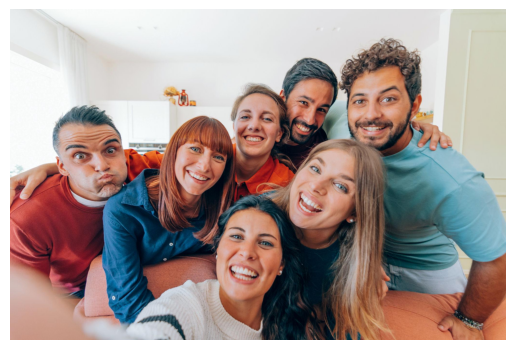

In [3]:
from matplotlib import pyplot as plt 
plt.imshow(img_rgb)
plt.axis('off')

In [4]:
detector=MTCNN()


2026-04-10 23:41:35.222824: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
faces=detector.detect_faces(img_rgb)
print("faces detected:",len(faces))

faces detected: 7


(-0.5, 2047.5, 1364.5, -0.5)

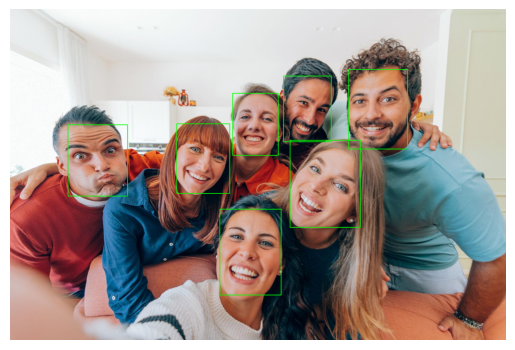

In [6]:
for face in faces:
    x,y,w,h=face['box']
    x,y=max(0,x),max(0,y)
    cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(0,255,0),2)
plt.imshow(img_rgb)
plt.axis('off')

In [7]:
model=InceptionResnetV1(pretrained='vggface2').eval()

  0%|          | 0.00/107M [00:00<?, ?B/s]

In [8]:
embeddings = []

for face_data in faces:
    x, y, w, h = face_data['box']
    
    x, y = max(0, x), max(0, y)
    
    face = img_rgb[y:y+h, x:x+w]
    
    face = cv2.resize(face, (160, 160))
    face = face / 255.0
    
    face = np.transpose(face, (2, 0, 1))
    face = np.expand_dims(face, axis=0)
    
    face_tensor = torch.tensor(face).float()
    
    embedding = model(face_tensor)
    
    embeddings.append(embedding)

In [9]:
for i in range(len(embeddings)):
    for j in range(i+1, len(embeddings)):
        sim = torch.nn.functional.cosine_similarity(embeddings[i], embeddings[j])
        print(f"Face {i} vs Face {j} similarity:", sim.item())

Face 0 vs Face 1 similarity: 0.05225786566734314
Face 0 vs Face 2 similarity: -0.14692066609859467
Face 0 vs Face 3 similarity: 0.20933014154434204
Face 0 vs Face 4 similarity: 0.19577980041503906
Face 0 vs Face 5 similarity: 0.0626787394285202
Face 0 vs Face 6 similarity: 0.06661568582057953
Face 1 vs Face 2 similarity: -0.06066461652517319
Face 1 vs Face 3 similarity: 0.0714675635099411
Face 1 vs Face 4 similarity: 0.013148389756679535
Face 1 vs Face 5 similarity: 0.12397237867116928
Face 1 vs Face 6 similarity: 0.35326069593429565
Face 2 vs Face 3 similarity: 0.1544838845729828
Face 2 vs Face 4 similarity: 0.28026846051216125
Face 2 vs Face 5 similarity: -0.10797670483589172
Face 2 vs Face 6 similarity: 0.1583748757839203
Face 3 vs Face 4 similarity: 0.17078933119773865
Face 3 vs Face 5 similarity: -0.048444509506225586
Face 3 vs Face 6 similarity: 0.0678524300456047
Face 4 vs Face 5 similarity: 0.045204922556877136
Face 4 vs Face 6 similarity: 0.24948786199092865
Face 5 vs Face 6 s

In [10]:
labels=[]
known_embeddings=[]
names=[]

In [11]:
threshold = 0.7
person_count = 0

for emb in embeddings:
    found = False
    
    for i, known_emb in enumerate(known_embeddings):
        sim = torch.nn.functional.cosine_similarity(emb, known_emb)
        
        if sim > threshold:
            labels.append(names[i])
            found = True
            break
    
    if not found:
        person_count += 1
        name = f"Person {person_count}"
        
        known_embeddings.append(emb)
        names.append(name)
        labels.append(name)

(-0.5, 2047.5, 1364.5, -0.5)

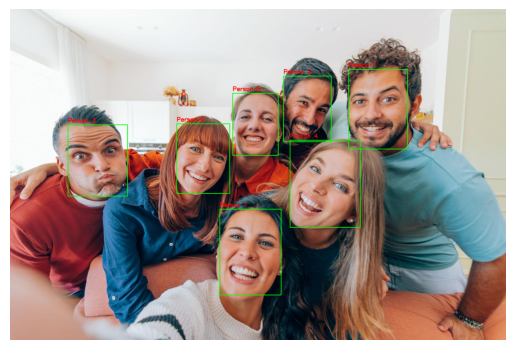

In [12]:
for face_data, name in zip(faces, labels):
    x, y, w, h = face_data['box']
    
    x, y = max(0, x), max(0, y)
    
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    cv2.putText(img_rgb, name, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (255, 0, 0), 2)

plt.imshow(img_rgb)
plt.axis('off')